# Wine Quality Prediction — Regression

## Project A: Regression with MLflow

The goal of this project is to predict white wine quality as a numerical value
using physicochemical properties.

The project follows an experiment-driven workflow:

- establish simple baselines;
- develop and compare neural networks;
- track experiments with MLflow;
- tune promising configurations;
- select the best model using validation performance;
- evaluate the winner once on the held-out test set;
- register the final model.

## Imports

In [112]:
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import mlflow
import mlflow.sklearn

from mlflow.models import infer_signature

from sklearn.dummy import DummyRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
)

In [113]:
# Constants
RANDOM_STATE = 42

TEST_SIZE = 0.20

# After removing the 20% test set,
# use 25% of the remaining 80% as validation.
# This gives us approximately:
# 60% train / 20% validation / 20% test
VALIDATION_SIZE = 0.25



In [114]:
# mlflow configuration
MLFLOW_TRACKING_URI = "http://127.0.0.1:5000"
EXPERIMENT_NAME = "Wine Quality - Regression"

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)

experiment = mlflow.set_experiment(
    EXPERIMENT_NAME
)

print("Tracking URI:", mlflow.get_tracking_uri())
print("Experiment:", experiment.name)
print("Experiment ID:", experiment.experiment_id)

2026/09/03 20:25:49 INFO mlflow.tracking.fluent: Experiment with name 'Wine Quality - Regression' does not exist. Creating a new experiment.


Tracking URI: http://127.0.0.1:5000
Experiment: Wine Quality - Regression
Experiment ID: 1


## EDA

In [115]:
# data 
data = pd.read_csv("https://raw.githubusercontent.com/mlflow/mlflow/master/tests/datasets/winequality-white.csv", sep=";")

In [116]:
data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [117]:
data.shape

(4898, 12)

In [118]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         4898 non-null   float64
 1   volatile acidity      4898 non-null   float64
 2   citric acid           4898 non-null   float64
 3   residual sugar        4898 non-null   float64
 4   chlorides             4898 non-null   float64
 5   free sulfur dioxide   4898 non-null   float64
 6   total sulfur dioxide  4898 non-null   float64
 7   density               4898 non-null   float64
 8   pH                    4898 non-null   float64
 9   sulphates             4898 non-null   float64
 10  alcohol               4898 non-null   float64
 11  quality               4898 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 459.3 KB


In [119]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,4898.0,6.854788,0.843868,3.80000,6.300000,6.80000,7.3000,14.20000
volatile acidity,4898.0,0.278241,0.100795,0.08000,0.210000,0.26000,0.3200,1.10000
citric acid,4898.0,0.334192,0.121020,0.00000,0.270000,0.32000,0.3900,1.66000
residual sugar,4898.0,6.391415,5.072058,0.60000,1.700000,5.20000,9.9000,65.80000
chlorides,4898.0,0.045772,0.021848,0.00900,0.036000,0.04300,0.0500,0.34600
free sulfur dioxide,4898.0,35.308085,17.007137,2.00000,23.000000,34.00000,46.0000,289.00000
total sulfur dioxide,4898.0,138.360657,42.498065,9.00000,108.000000,134.00000,167.0000,440.00000
density,4898.0,0.994027,0.002991,0.98711,0.991723,0.99374,0.9961,1.03898
pH,4898.0,3.188267,0.151001,2.72000,3.090000,3.18000,3.2800,3.82000
sulphates,4898.0,0.489847,0.114126,0.22000,0.410000,0.47000,0.5500,1.08000


In [120]:
data.isna().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [121]:
quality_distribution = (
    data["quality"]
    .value_counts()
    .sort_index()
)

quality_distribution

quality
3      20
4     163
5    1457
6    2198
7     880
8     175
9       5
Name: count, dtype: int64

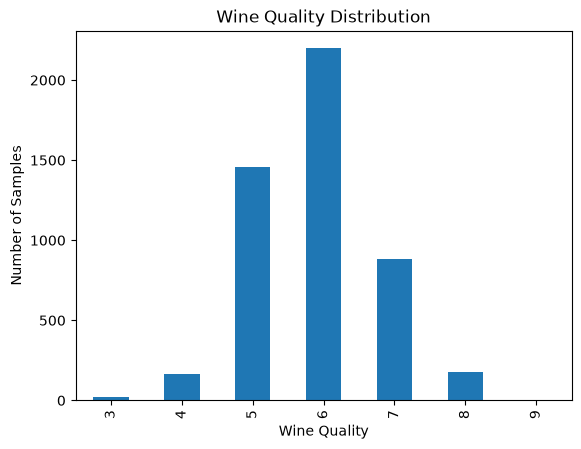

In [122]:
fig, ax = plt.subplots()

quality_distribution.plot(
    kind="bar",
    ax=ax
)

ax.set_xlabel("Wine Quality")
ax.set_ylabel("Number of Samples")
ax.set_title("Wine Quality Distribution")

plt.show()

In [123]:
X = data.drop(
    columns=["quality"]
)

y = data["quality"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

X shape: (4898, 11)
y shape: (4898,)

Features:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']


## Train/Validation/Test Split

In [124]:
X_dev, X_test, y_dev, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)
X_train, X_val, y_train, y_val = train_test_split(
    X_dev,
    y_dev,
    test_size=VALIDATION_SIZE,
    random_state=RANDOM_STATE
)
print("Train:")
print(X_train.shape, y_train.shape)

print("\nValidation:")
print(X_val.shape, y_val.shape)

print("\nTest:")
print(X_test.shape, y_test.shape)

Train:
(2938, 11) (2938,)

Validation:
(980, 11) (980,)

Test:
(980, 11) (980,)


## MLFLOW Configuration

In [125]:
mlflow.set_tracking_uri(
    MLFLOW_TRACKING_URI
)

experiment = mlflow.set_experiment(
    EXPERIMENT_NAME
)

print(
    "Tracking URI:",
    mlflow.get_tracking_uri()
)

print(
    "Experiment:",
    experiment.name
)

print(
    "Experiment ID:",
    experiment.experiment_id
)

Tracking URI: http://127.0.0.1:5000
Experiment: Wine Quality - Regression
Experiment ID: 1


In [126]:
def regression_metrics(y_true, y_pred):

    mse = mean_squared_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(mse)

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    r2 = r2_score(
        y_true,
        y_pred
    )

    return {
        "rmse": rmse,
        "mae": mae,
        "r2": r2
    }

## Experiment 00 - Dummy Regressor

In [127]:
dummy_model = DummyRegressor(
    strategy="mean"
)

with mlflow.start_run(
    run_name="00-DummyRegressor"
):


    # Train


    start_time = time.time()

    dummy_model.fit(
        X_train,
        y_train
    )

    training_time = (
        time.time() - start_time
    )



    # Predictions


    train_predictions = dummy_model.predict(
        X_train
    )

    prediction_start = time.time()

    val_predictions = dummy_model.predict(
        X_val
    )

    prediction_time = (
        time.time() - prediction_start
    )



    # Metrics


    train_metrics = regression_metrics(
        y_train,
        train_predictions
    )

    val_metrics = regression_metrics(
        y_val,
        val_predictions
    )



    # Log parameters


    mlflow.log_params({
        "strategy": "mean",
        "random_state": RANDOM_STATE,
        "test_size": TEST_SIZE,
        "validation_size": VALIDATION_SIZE
    })



    # Log metrics


    mlflow.log_metrics({

        "train_rmse":
            train_metrics["rmse"],

        "train_mae":
            train_metrics["mae"],

        "train_r2":
            train_metrics["r2"],

        "validation_rmse":
            val_metrics["rmse"],

        "validation_mae":
            val_metrics["mae"],

        "validation_r2":
            val_metrics["r2"],

        "training_time":
            training_time,

        "prediction_time":
            prediction_time
    })



    # Tags


    mlflow.set_tags({
        "project": "Project A - Regression",
        "model_type": "DummyRegressor",
        "model_family": "Baseline",
        "dataset": "White Wine Quality",
        "task": "Regression",
        "tuning_method": "None"
    })



    # Model signature


    input_example = X_train.head(5)

    example_prediction = dummy_model.predict(
        input_example
    )

    signature = infer_signature(
        input_example,
        example_prediction
    )



    # Log model


    mlflow.sklearn.log_model(
        sk_model=dummy_model,
        name="dummy_regressor",
        signature=signature,
        input_example=input_example
    )



    # Results


    print("Dummy Regressor")

    print(
        f"\nTrain RMSE:      "
        f"{train_metrics['rmse']:.4f}"
    )

    print(
        f"Validation RMSE: "
        f"{val_metrics['rmse']:.4f}"
    )

    print(
        f"Validation MAE:  "
        f"{val_metrics['mae']:.4f}"
    )

    print(
        f"Validation R²:   "
        f"{val_metrics['r2']:.4f}"
    )

    print(
        f"\nTraining Time:   "
        f"{training_time:.6f} s"
    )

Dummy Regressor

Train RMSE:      0.8937
Validation RMSE: 0.8658
Validation MAE:  0.6602
Validation R²:   -0.0008

Training Time:   0.001528 s
🏃 View run 00-DummyRegressor at: http://127.0.0.1:5000/#/experiments/1/runs/d64971a7470b44ffbfcfb836eec3519d
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


## Experiment 01 — Linear Regression

In [128]:
from sklearn.linear_model import LinearRegression

In [129]:
# Experiment 01: Linear Regression

linear_model = LinearRegression()

with mlflow.start_run(run_name="01-LinearRegression"):

    start_time = time.time()
    linear_model.fit(X_train, y_train)
    training_time = time.time() - start_time

    train_predictions = linear_model.predict(X_train)

    prediction_start = time.time()
    val_predictions = linear_model.predict(X_val)
    prediction_time = time.time() - prediction_start

    train_metrics = regression_metrics(
        y_train,
        train_predictions
    )

    val_metrics = regression_metrics(
        y_val,
        val_predictions
    )

    mlflow.log_params({
        "fit_intercept": linear_model.fit_intercept,
        "random_state": RANDOM_STATE,
        "test_size": TEST_SIZE,
        "validation_size": VALIDATION_SIZE
    })

    mlflow.log_metrics({
        "train_rmse": train_metrics["rmse"],
        "train_mae": train_metrics["mae"],
        "train_r2": train_metrics["r2"],
        "validation_rmse": val_metrics["rmse"],
        "validation_mae": val_metrics["mae"],
        "validation_r2": val_metrics["r2"],
        "training_time": training_time,
        "prediction_time": prediction_time
    })

    mlflow.set_tags({
        "project": "Project A - Regression",
        "model_type": "LinearRegression",
        "model_family": "Linear Model",
        "dataset": "White Wine Quality",
        "task": "Regression",
        "tuning_method": "None",
        "scaled": "False"
    })

    coefficients = pd.DataFrame({
        "feature": X_train.columns,
        "coefficient": linear_model.coef_
    }).sort_values(
        "coefficient",
        key=abs,
        ascending=False
    )

    mlflow.log_table(
        coefficients,
        "coefficients.json"
    )

    fig, ax = plt.subplots()

    ax.scatter(
        y_val,
        val_predictions,
        alpha=0.4
    )

    minimum = min(
        y_val.min(),
        val_predictions.min()
    )

    maximum = max(
        y_val.max(),
        val_predictions.max()
    )

    ax.plot(
        [minimum, maximum],
        [minimum, maximum],
        linestyle="--"
    )

    ax.set_xlabel("Actual Quality")
    ax.set_ylabel("Predicted Quality")
    ax.set_title("Linear Regression — Actual vs Predicted")

    mlflow.log_figure(
        fig,
        "plots/actual_vs_predicted.png"
    )

    plt.close(fig)

    residuals = y_val - val_predictions

    fig, ax = plt.subplots()

    ax.scatter(
        val_predictions,
        residuals,
        alpha=0.4
    )

    ax.axhline(
        y=0,
        linestyle="--"
    )

    ax.set_xlabel("Predicted Quality")
    ax.set_ylabel("Residual")
    ax.set_title("Linear Regression — Residuals")

    mlflow.log_figure(
        fig,
        "plots/residuals.png"
    )

    plt.close(fig)

    input_example = X_train.head(5)
    example_prediction = linear_model.predict(input_example)

    signature = infer_signature(
        input_example,
        example_prediction
    )

    mlflow.sklearn.log_model(
        sk_model=linear_model,
        name="linear_regression",
        signature=signature,
        input_example=input_example
    )

    print("Linear Regression")
    print(f"Train RMSE:      {train_metrics['rmse']:.4f}")
    print(f"Validation RMSE: {val_metrics['rmse']:.4f}")
    print(f"Validation MAE:  {val_metrics['mae']:.4f}")
    print(f"Validation R²:   {val_metrics['r2']:.4f}")
    print(f"Training Time:   {training_time:.6f} s")

Linear Regression
Train RMSE:      0.7563
Validation RMSE: 0.7412
Validation MAE:  0.5676
Validation R²:   0.2665
Training Time:   0.002785 s
🏃 View run 01-LinearRegression at: http://127.0.0.1:5000/#/experiments/1/runs/8aae8470cafd40c5bf070204ffb5bd64
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


## Experiment 02 — Baseline ANN

In [136]:
import tensorflow as tf
import keras
import mlflow.keras

tf.config.optimizer.set_experimental_options({
    "disable_meta_optimizer": True
})

keras.utils.set_random_seed(RANDOM_STATE)

In [137]:
X_train_nn = X_train.to_numpy(dtype="float32")
X_val_nn = X_val.to_numpy(dtype="float32")

y_train_nn = y_train.to_numpy(dtype="float32")
y_val_nn = y_val.to_numpy(dtype="float32")

In [138]:
EPOCHS = 50
BATCH_SIZE = 64
LEARNING_RATE = 0.01
MOMENTUM = 0.0

In [139]:
normalizer = keras.layers.Normalization(axis=-1)
normalizer.adapt(X_train_nn)

ann_model = keras.Sequential([
    keras.Input(shape=(X_train_nn.shape[1],)),
    normalizer,
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dense(1)
])

ann_model.compile(
    optimizer=keras.optimizers.SGD(
        learning_rate=LEARNING_RATE,
        momentum=MOMENTUM
    ),
    loss="mean_squared_error",
    metrics=[
        keras.metrics.RootMeanSquaredError(name="rmse"),
        keras.metrics.MeanAbsoluteError(name="mae")
    ]
)

ann_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization_3 (Normalization) │ (None, 11)             │            23 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 856 (3.35 KB)

 Trainable params: 833 (3.25 KB)

 Non-trainable params: 23 (96.00 B)

In [141]:
with mlflow.start_run(run_name="02-ANN-Baseline"):

    start_time = time.time()

    history = ann_model.fit(
        X_train_nn,
        y_train_nn,
        validation_data=(X_val_nn, y_val_nn),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=0
    )

    training_time = time.time() - start_time

    train_predictions = ann_model.predict(
        X_train_nn,
        verbose=0
    ).ravel()

    prediction_start = time.time()

    val_predictions = ann_model.predict(
        X_val_nn,
        verbose=0
    ).ravel()

    prediction_time = time.time() - prediction_start

    train_metrics = regression_metrics(
        y_train_nn,
        train_predictions
    )

    val_metrics = regression_metrics(
        y_val_nn,
        val_predictions
    )

    mlflow.log_params({
        "architecture": "64-1",
        "hidden_layers": 1,
        "hidden_units": 64,
        "activation": "relu",
        "optimizer": "SGD",
        "learning_rate": LEARNING_RATE,
        "momentum": MOMENTUM,
        "epochs": EPOCHS,
        "batch_size": BATCH_SIZE,
        "normalization": "Keras Normalization",
        "random_state": RANDOM_STATE
    })

    mlflow.log_metrics({
        "train_rmse": train_metrics["rmse"],
        "train_mae": train_metrics["mae"],
        "train_r2": train_metrics["r2"],
        "validation_rmse": val_metrics["rmse"],
        "validation_mae": val_metrics["mae"],
        "validation_r2": val_metrics["r2"],
        "training_time": training_time,
        "prediction_time": prediction_time
    })

    mlflow.set_tags({
        "project": "Project A - Regression",
        "model_type": "Neural Network",
        "model_family": "ANN",
        "dataset": "White Wine Quality",
        "task": "Regression",
        "tuning_method": "None",
        "optimizer": "SGD"
    })

    for epoch in range(EPOCHS):

        mlflow.log_metric(
            "epoch_train_rmse",
            history.history["rmse"][epoch],
            step=epoch + 1
        )

        mlflow.log_metric(
            "epoch_validation_rmse",
            history.history["val_rmse"][epoch],
            step=epoch + 1
        )

        mlflow.log_metric(
            "epoch_train_loss",
            history.history["loss"][epoch],
            step=epoch + 1
        )

        mlflow.log_metric(
            "epoch_validation_loss",
            history.history["val_loss"][epoch],
            step=epoch + 1
        )

    fig, ax = plt.subplots()

    ax.plot(
        history.history["rmse"],
        label="Training RMSE"
    )

    ax.plot(
        history.history["val_rmse"],
        label="Validation RMSE"
    )

    ax.set_xlabel("Epoch")
    ax.set_ylabel("RMSE")
    ax.set_title("Baseline ANN — Learning Curve")
    ax.legend()

    mlflow.log_figure(
        fig,
        "plots/learning_curve.png"
    )

    plt.close(fig)

    fig, ax = plt.subplots()

    ax.scatter(
        y_val_nn,
        val_predictions,
        alpha=0.4
    )

    minimum = min(
        y_val_nn.min(),
        val_predictions.min()
    )

    maximum = max(
        y_val_nn.max(),
        val_predictions.max()
    )

    ax.plot(
        [minimum, maximum],
        [minimum, maximum],
        linestyle="--"
    )

    ax.set_xlabel("Actual Quality")
    ax.set_ylabel("Predicted Quality")
    ax.set_title("Baseline ANN — Actual vs Predicted")

    mlflow.log_figure(
        fig,
        "plots/actual_vs_predicted.png"
    )

    plt.close(fig)

    residuals = y_val_nn - val_predictions

    fig, ax = plt.subplots()

    ax.scatter(
        val_predictions,
        residuals,
        alpha=0.4
    )

    ax.axhline(
        y=0,
        linestyle="--"
    )

    ax.set_xlabel("Predicted Quality")
    ax.set_ylabel("Residual")
    ax.set_title("Baseline ANN — Residuals")

    mlflow.log_figure(
        fig,
        "plots/residuals.png"
    )

    plt.close(fig)

input_example = X_train_nn[:5]

example_prediction = ann_model.predict(
    input_example,
    verbose=0
)

signature = infer_signature(
    input_example,
    example_prediction
)

mlflow.keras.log_model(
    model=ann_model,
    name="baseline_ann",
    signature=signature
)

input_example_df = pd.DataFrame(
    input_example,
    columns=X_train.columns
)

mlflow.log_table(
    input_example_df,
    "input_example.json"
)

print("Baseline ANN")
print(f"Train RMSE:      {train_metrics['rmse']:.4f}")
print(f"Validation RMSE: {val_metrics['rmse']:.4f}")
print(f"Validation MAE:  {val_metrics['mae']:.4f}")
print(f"Validation R²:   {val_metrics['r2']:.4f}")
print(f"Training Time:   {training_time:.4f} s")
print(f"Prediction Time: {prediction_time:.6f} s")

🏃 View run 02-ANN-Baseline at: http://127.0.0.1:5000/#/experiments/1/runs/1aaeb4c82e11405f9dace0b4b1135c17
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
Baseline ANN
Train RMSE:      0.6702
Validation RMSE: 0.6773
Validation MAE:  0.5202
Validation R²:   0.3876
Training Time:   3.5124 s
Prediction Time: 0.041950 s
